# Adaptive Alpha vs Baselines Analysis
This notebook compares the results of the Adaptive Alpha repair strategy against Vanilla VC and Classic Weighted VC (fixed alpha=0.5).

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import json

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 8]

## 1. Pull Results
Run this cell to pull the latest results from the remote server.

In [21]:
# !python ../scripts/slurm_manager.py pull --results --name adaptive_alpha_comparison_v1

## 2. Load Results
The results are stored as nested JSON files in `../results/adaptive_alpha_comparison_v1/`.

In [22]:
results_dir = "../results/adaptive_alpha_comparison_v1"
# Search recursively for result_*.json
result_files = glob.glob(os.path.join(results_dir, "**", "result_*.json"), recursive=True)
print(f"Found {len(result_files)} result files.")

data = []
for f in result_files:
    with open(f, 'r') as j:
        try:
            res = json.load(j)
            exp_name = res.get('experiment_name', '')
            
            # Determine repairer type - Be careful with the experiment prefix!
            # exp_name is like 'adaptive_alpha_comparison_v1/adult_aim_eps0.1_classic'
            parts = exp_name.split('/')
            last_part = parts[-1]
            
            if last_part.endswith('_adaptive'):
                repairer_type = 'adaptive'
            elif last_part.endswith('_vanilla'):
                repairer_type = 'vanilla_vc'
            elif last_part.endswith('_classic'):
                repairer_type = 'classic_vc'
            else:
                repairer_type = 'unknown'
            
            # Parse algorithm and eps from last_part (e.g., adult_aim_eps0.1_adaptive)
            name_parts = last_part.split('_')
            dataset = res.get('dataset_name', name_parts[0])
            algo = name_parts[1] if len(name_parts) > 1 else 'unknown'
            eps_str = [p for p in name_parts if 'eps' in p][0].replace('eps', '') if any('eps' in p for p in name_parts) else '0'
            eps = float(eps_str)
            
            info = {
                'dataset': dataset,
                'algorithm': algo,
                'eps': eps,
                'repairer': repairer_type,
                'deletion_ratio': res.get('deletion_ratio', {}).get('ratio', 0),
                'marginal_error_repaired': res.get('marginals_error', {}).get('repaired_avg', 0),
                'marginal_error_synthetic': res.get('marginals_error', {}).get('synthetic_avg', 0),
                'tvd_repaired': res.get('tvd_2way', {}).get('repaired_avg', 0),
                'tvd_synthetic': res.get('tvd_2way', {}).get('synthetic_avg', 0),
                'error_improvement': res.get('marginals_error', {}).get('synthetic_avg', 0) - res.get('marginals_error', {}).get('repaired_avg', 0),
                'repair_runtime': res.get('runtimes', {}).get('repairing', 0),
                'violations_synthetic': res.get('violations', {}).get('synthetic', 0),
                'accuracy_drop': res.get('ml_accuracy', {}).get('synthetic', {}).get('random_forest', 0) - res.get('ml_accuracy', {}).get('repaired', {}).get('random_forest', 0)
            }
            data.append(info)
        except Exception as e:
            print(f"Error parsing {f}: {e}")

df = pd.DataFrame(data)
if not df.empty:
    # Sort for consistent plotting
    df = df.sort_values(['dataset', 'algorithm', 'eps', 'repairer'])
    display(df.head())
else:
    print("No results loaded.")

Found 65 result files.


,dataset,algorithm,eps,repairer,deletion_ratio,marginal_error_repaired,marginal_error_synthetic,tvd_repaired,tvd_synthetic,error_improvement,repair_runtime,violations_synthetic,accuracy_drop
0,adult,aim,0.5,classic_vc,0.067442,58.477622,58.014134,0.047643,0.043215,-0.463488,1981.918509,28643605,-0.001310
1,adult,aim,0.5,vanilla_vc,0.057451,59.263298,58.014134,0.046323,0.043215,-1.249164,1755.926523,28643605,-0.001024
2,adult,aim,1.0,classic_vc,0.040969,0.297658,0.300442,0.032776,0.031534,0.002784,1356.950258,25712793,-0.000737
3,adult,aim,1.0,classic_vc,0.040969,0.297658,0.300442,0.032776,0.031534,0.002784,1350.250056,25712793,-0.000737
4,adult,aim,1.0,vanilla_vc,0.040969,0.297658,0.300442,0.032776,0.031534,0.002784,1254.710094,25712793,-0.000737


## 3. Comparison Visualizations

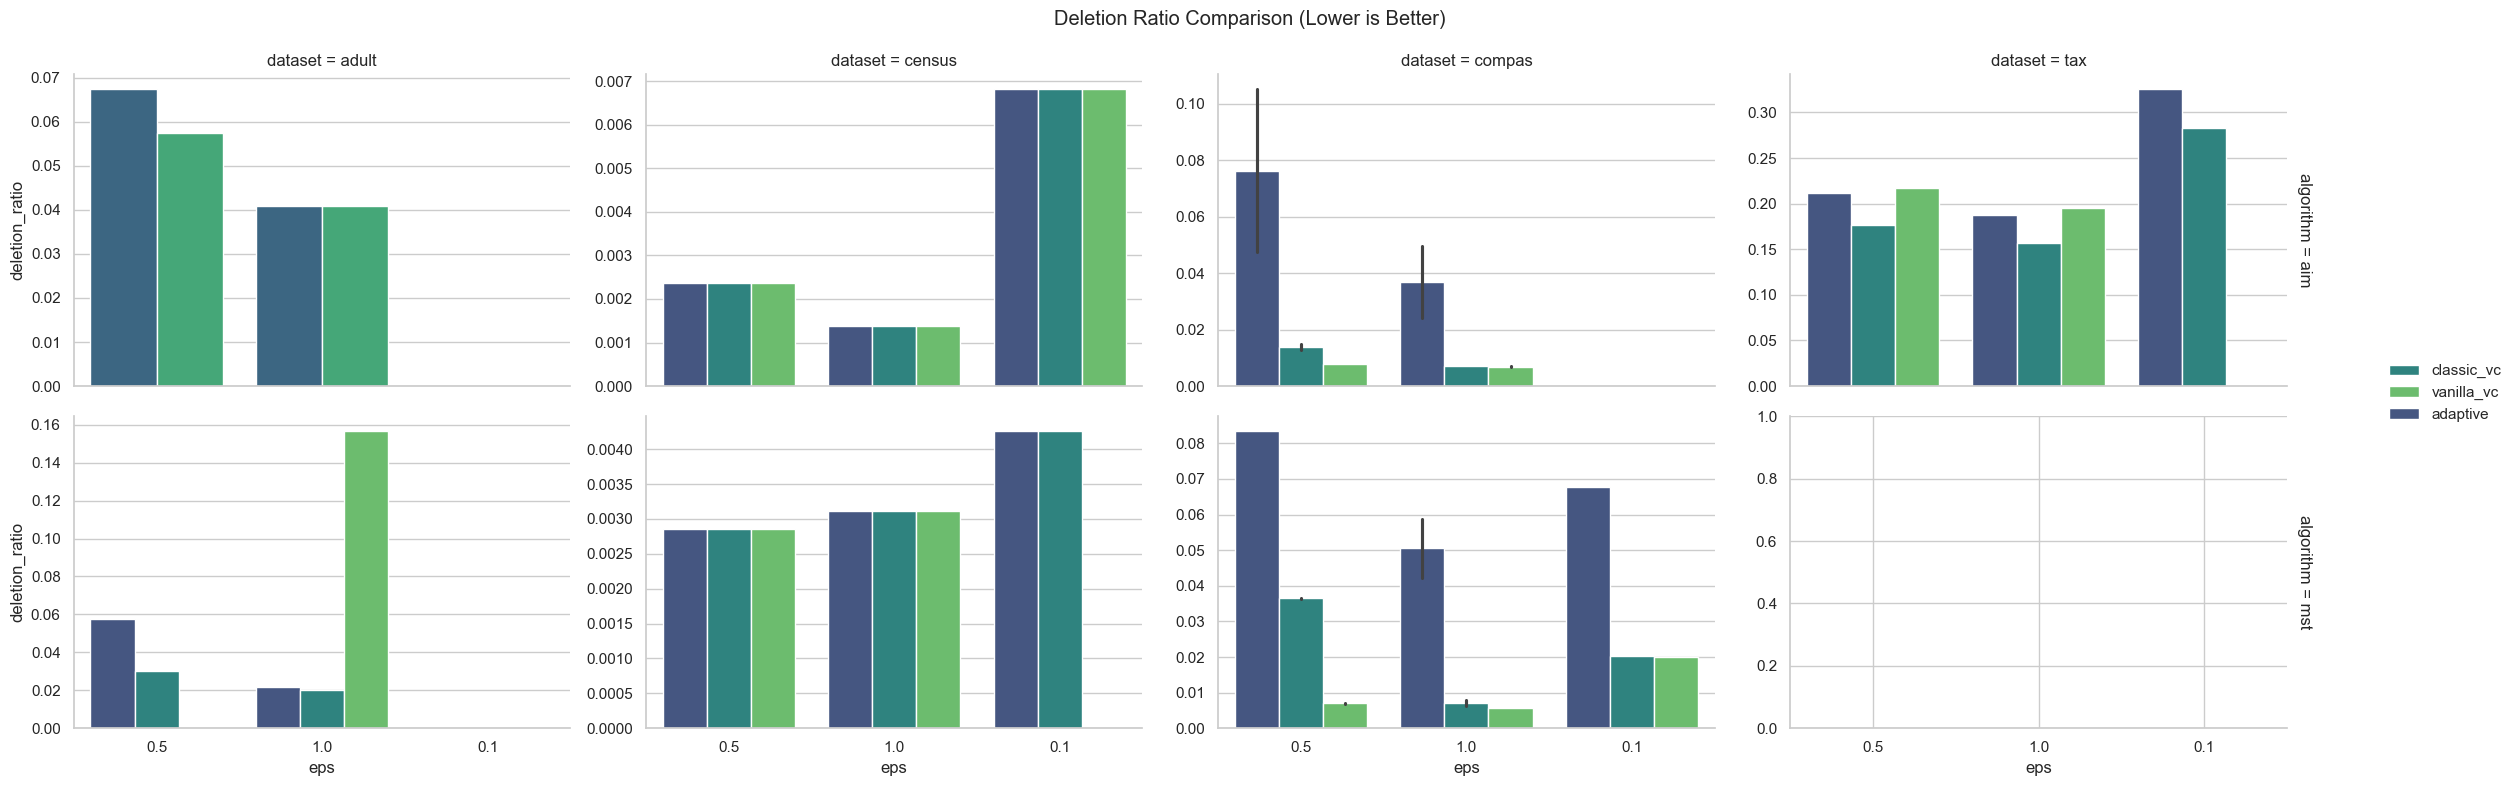

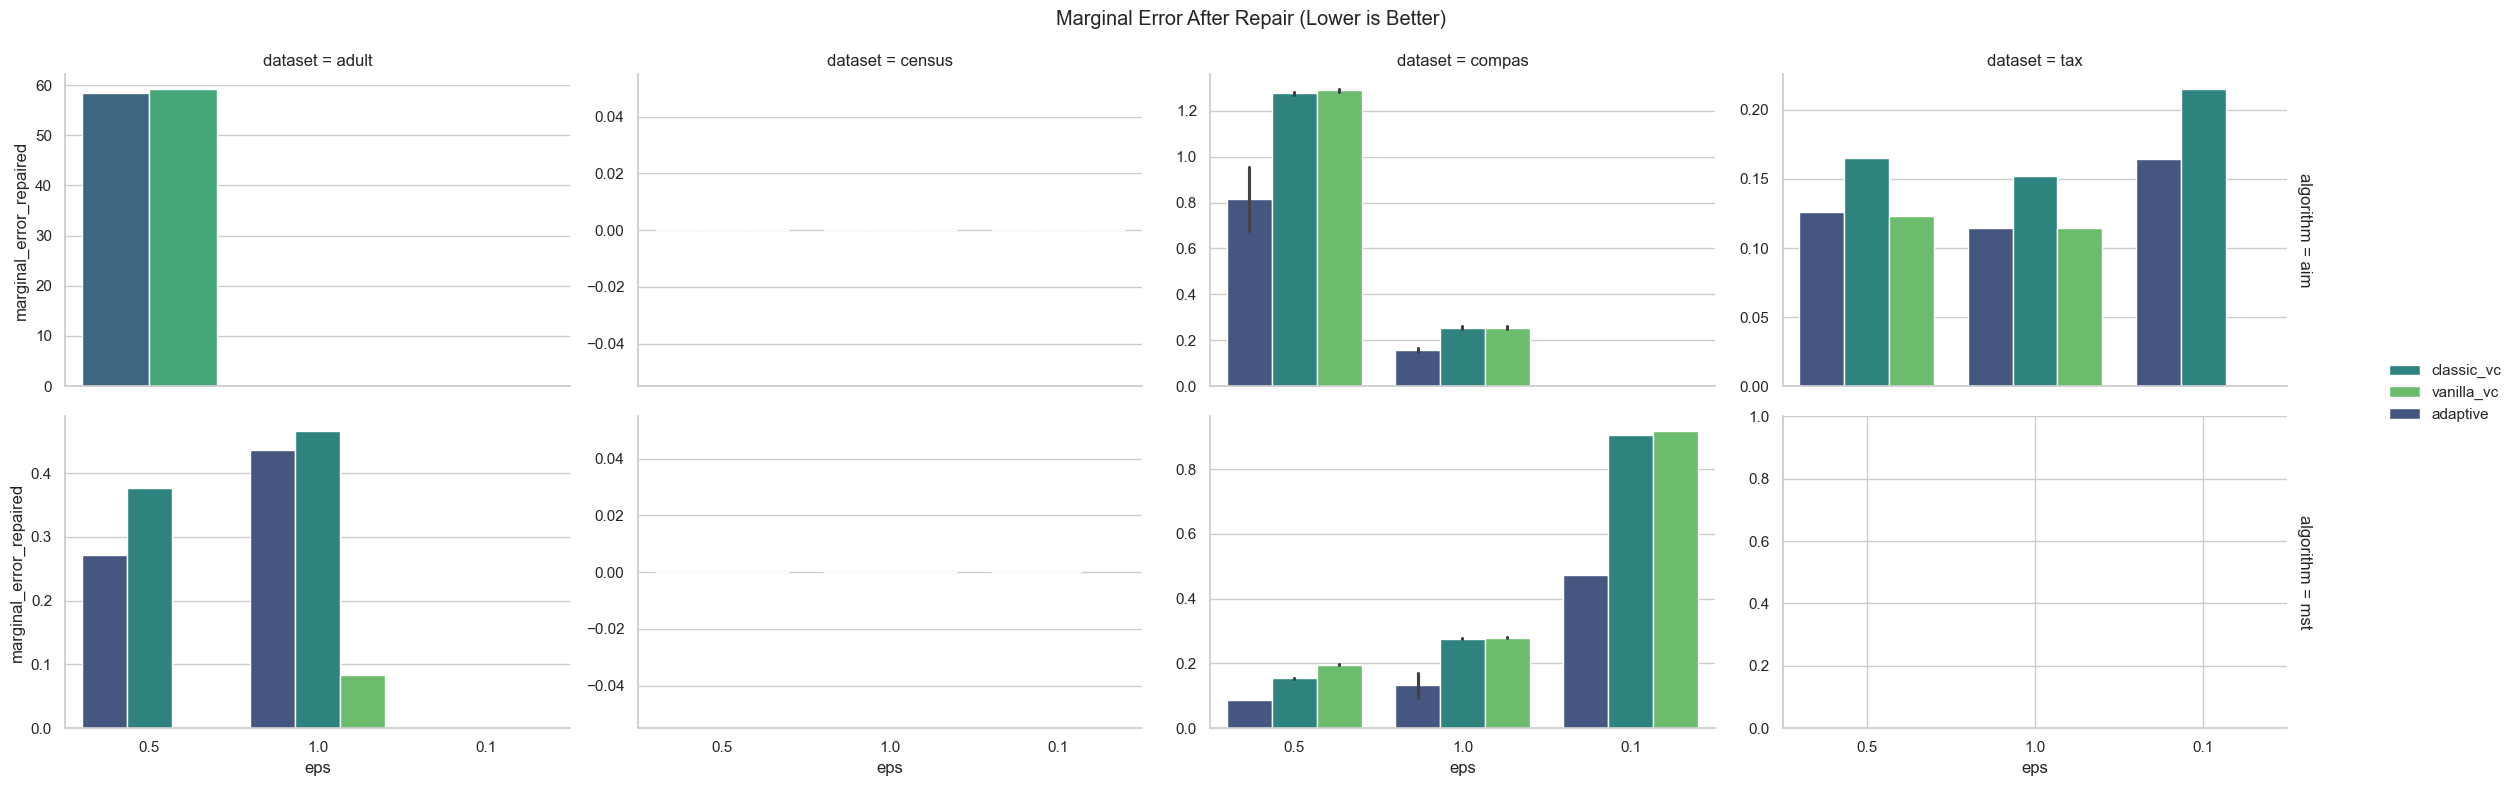

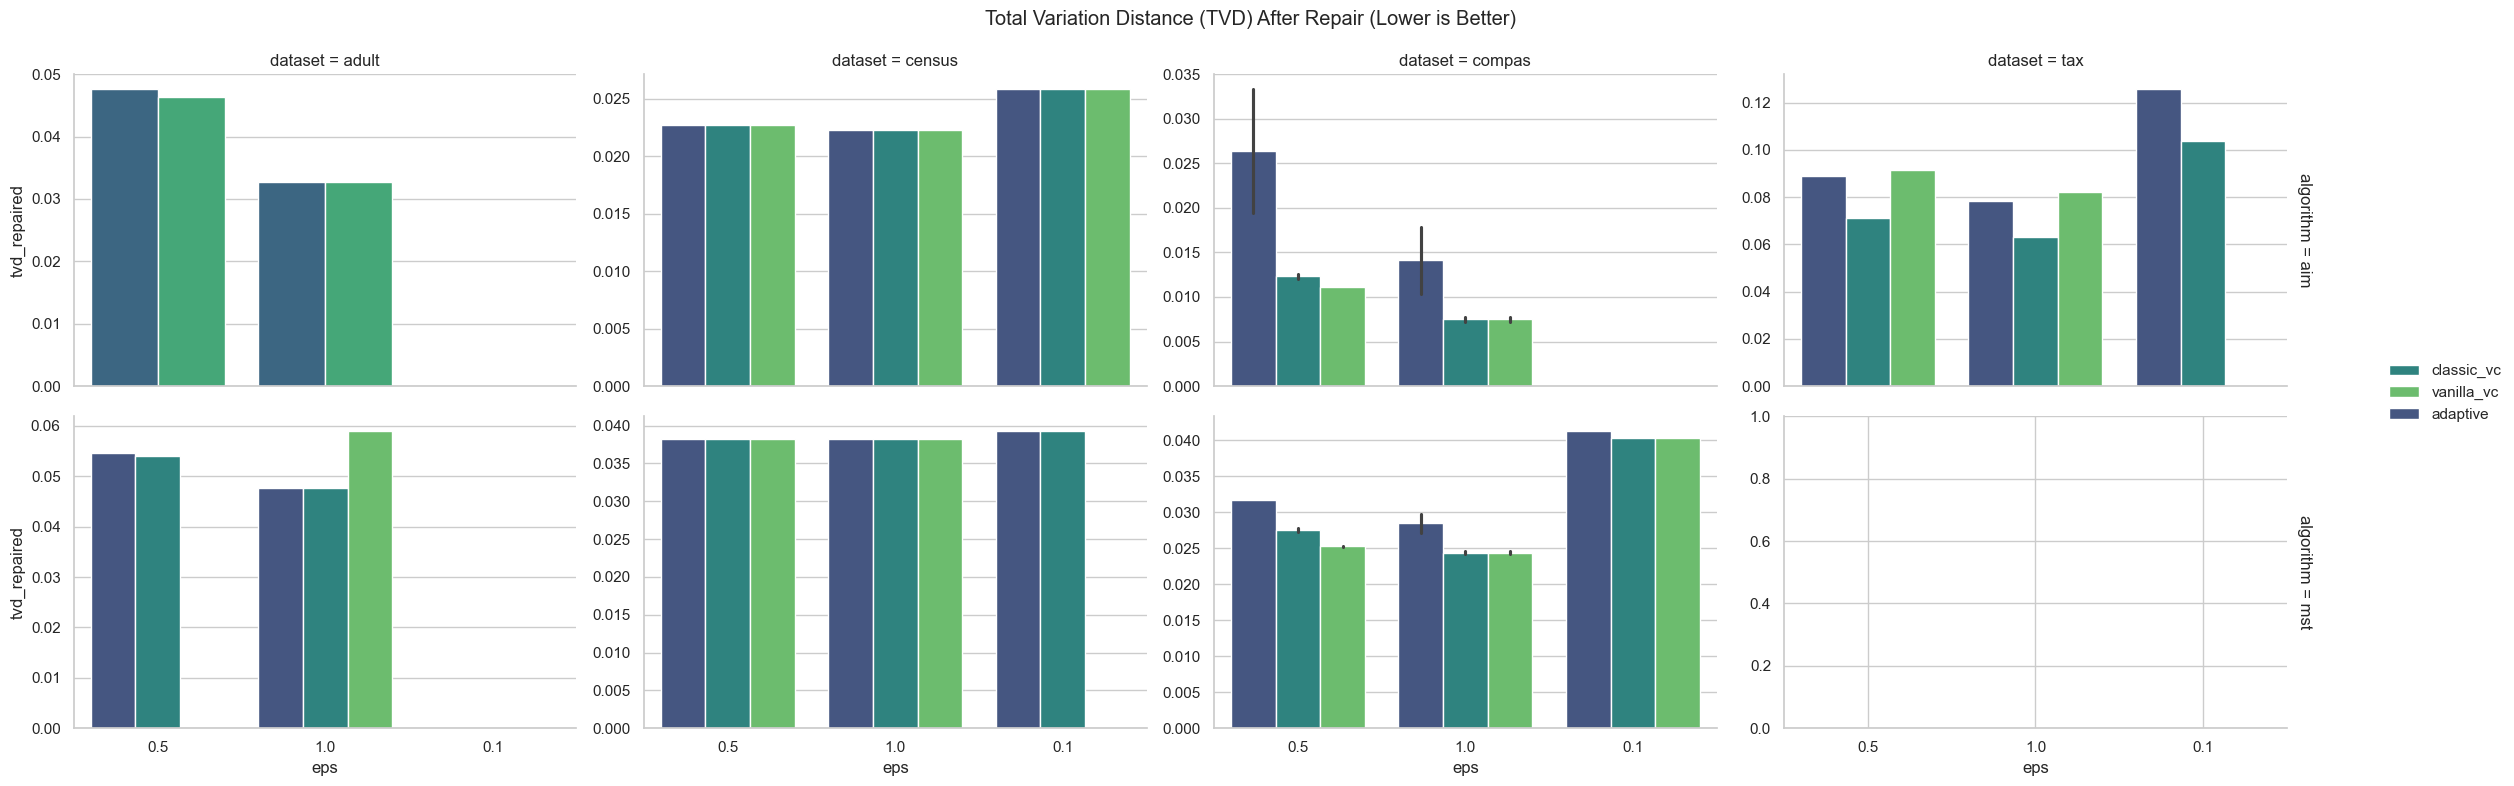

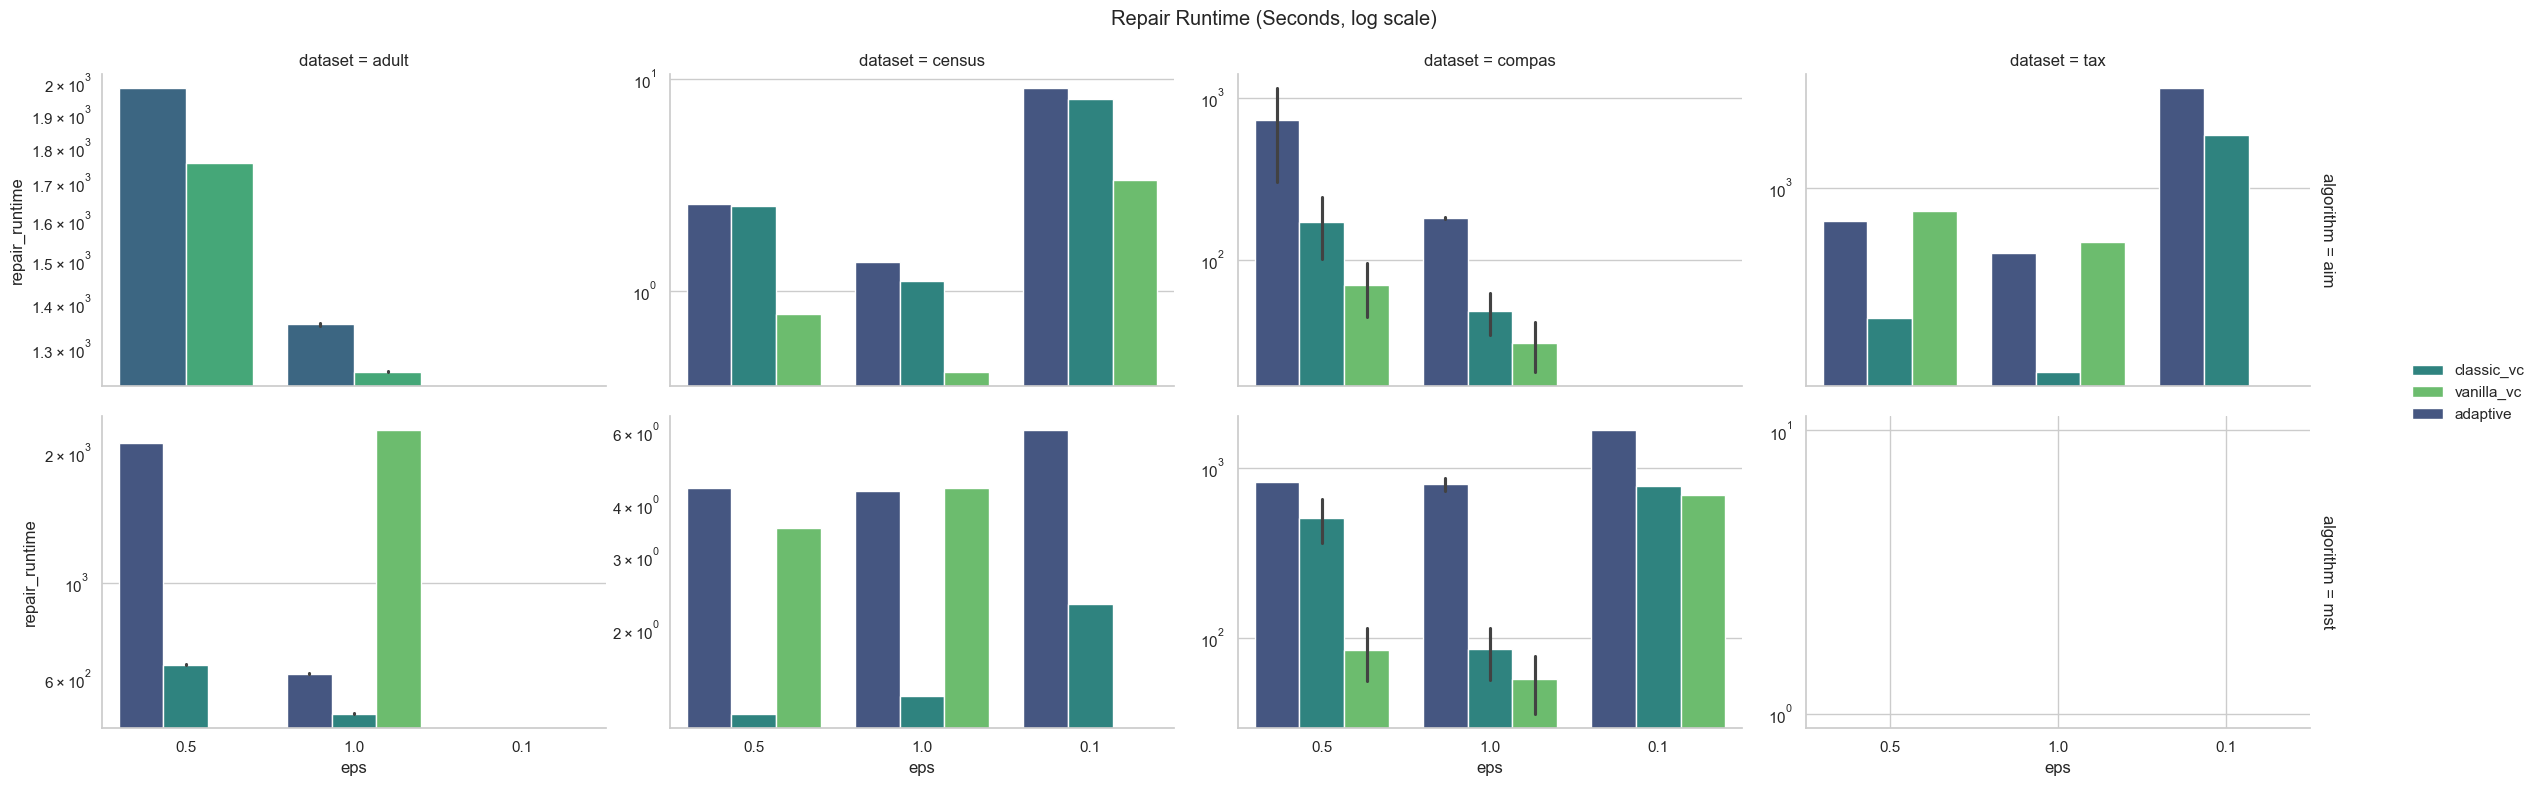

In [23]:
if not df.empty:
    # 3.1 Deletion Ratio (Efficiency)
    g = sns.FacetGrid(df, col="dataset", row="algorithm", height=4, aspect=1.5, sharey=False, margin_titles=True)
    g.map_dataframe(sns.barplot, x="eps", y="deletion_ratio", hue="repairer", palette="viridis")
    g.add_legend()
    g.fig.suptitle("Deletion Ratio Comparison (Lower is Better)")
    plt.subplots_adjust(top=0.9)
    plt.show()

    # 3.2 Marginal Error (Utility)
    g = sns.FacetGrid(df, col="dataset", row="algorithm", height=4, aspect=1.5, sharey=False, margin_titles=True)
    g.map_dataframe(sns.barplot, x="eps", y="marginal_error_repaired", hue="repairer", palette="viridis")
    g.add_legend()
    g.fig.suptitle("Marginal Error After Repair (Lower is Better)")
    plt.subplots_adjust(top=0.9)
    plt.show()

    # 3.3 TVD (Utility)
    g = sns.FacetGrid(df, col="dataset", row="algorithm", height=4, aspect=1.5, sharey=False, margin_titles=True)
    g.map_dataframe(sns.barplot, x="eps", y="tvd_repaired", hue="repairer", palette="viridis")
    g.add_legend()
    g.fig.suptitle("Total Variation Distance (TVD) After Repair (Lower is Better)")
    plt.subplots_adjust(top=0.9)
    plt.show()

    # 3.4 Runtime (Speed)
    g = sns.FacetGrid(df, col="dataset", row="algorithm", height=4, aspect=1.5, sharey=False, margin_titles=True)
    g.map_dataframe(sns.barplot, x="eps", y="repair_runtime", hue="repairer", palette="viridis")
    g.add_legend()
    g.set(yscale="log")
    g.fig.suptitle("Repair Runtime (Seconds, log scale)")
    plt.subplots_adjust(top=0.9)
    plt.show()

## 4. Conclusion Table
Aggregated metrics comparing the three strategies.

In [24]:
if not df.empty:
    summary = df.groupby('repairer')[['deletion_ratio', 'marginal_error_repaired', 'tvd_repaired', 'repair_runtime']].mean()
    print("--- Overall Strategy Comparison ---")
    display(summary)
    
    # Best strategy per dataset/algorithm/eps
    print("\n--- Best Repairer per Dataset & Algorithm (Minimized Deletion) ---")
    # Avoid using idxmin on grouped object directly as it might return multiple columns
    best_indices = df.groupby(['dataset', 'algorithm', 'eps'])['deletion_ratio'].idxmin()
    best_df = df.loc[best_indices]
    display(best_df[['dataset', 'algorithm', 'eps', 'repairer', 'deletion_ratio', 'tvd_repaired']])

--- Overall Strategy Comparison ---


,deletion_ratio,marginal_error_repaired,tvd_repaired,repair_runtime
repairer,,,,
adaptive,0.062892,0.181683,0.037063,564.376298
classic_vc,0.049619,2.845642,0.038571,619.063389
vanilla_vc,0.038140,2.681362,0.036669,394.073311



--- Best Repairer per Dataset & Algorithm (Minimized Deletion) ---


,dataset,algorithm,eps,repairer,deletion_ratio,tvd_repaired
1,adult,aim,0.5,vanilla_vc,0.057451,0.046323
2,adult,aim,1.0,classic_vc,0.040969,0.032776
7,adult,mst,0.5,vanilla_vc,0.030240,0.054089
12,adult,mst,1.0,vanilla_vc,0.020331,0.047599
14,census,aim,0.1,adaptive,0.006820,0.025838
17,census,aim,0.5,adaptive,0.002360,0.022716
20,census,aim,1.0,adaptive,0.001380,0.022254
23,census,mst,0.1,adaptive,0.004260,0.039277
25,census,mst,0.5,adaptive,0.002860,0.038287
28,census,mst,1.0,adaptive,0.003120,0.038195


In [25]:
len(df)

65